# Notebook 08 — U-Net Training on TuSimple

Trains a U-Net for binary lane segmentation on the TuSimple dataset.
The trained model and metrics are saved for comparison against our classical pipeline.
Note: This notebook is meant to be run from colab

In [ ]:
!nvidia-smi

Sun May 10 14:24:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install -q kaggle

In [ ]:
import os
import shutil

if not os.path.exists("/root/.kaggle"):
    os.makedirs("/root/.kaggle")

if os.path.exists("/content/kaggle.json"):
    shutil.move("/content/kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("Kaggle credentials installed")
elif os.path.exists("/root/.kaggle/kaggle.json"):
    print("Kaggle credentials already in place")
else:
    print("ERROR: Upload kaggle.json via the Files panel, then re-run this cell")

# Verify auth
!kaggle datasets list -s tusimple | head -3

Kaggle credentials already in place
ref                                             title                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------  -----------------------------  -----------  --------------------------  -------------  ---------  ---------------  
manideep1108/tusimple                           TuSimple                       23235794837  2021-11-22 15:30:25.957000          29311        143  0.75             


In [ ]:
import os

if not os.path.exists("/content/lane-detection-cv"):
    !git clone https://github.com/devrugu/lane-detection-cv.git /content/lane-detection-cv
else:
    print("Repo already cloned")

os.chdir("/content/lane-detection-cv")
print(f"Working directory: {os.getcwd()}")
!ls

Repo already cloned
Working directory: /content/lane-detection-cv
data	 notebooks  report	      results  tests
LICENSE  README.md  requirements.txt  src


In [ ]:
# Mount Google Drive — saves persist across Colab disconnects
from google.colab import drive
drive.mount('/content/drive')

# Create our project folder in Drive (or reuse if it exists)
from pathlib import Path
DRIVE_PROJECT = Path('/content/drive/MyDrive/lane-detection-cv')
DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)

# Subfolders
(DRIVE_PROJECT / "checkpoints").mkdir(exist_ok=True)
(DRIVE_PROJECT / "results").mkdir(exist_ok=True)
(DRIVE_PROJECT / "data" / "tusimple" / "splits").mkdir(parents=True, exist_ok=True)

print(f"Drive project folder: {DRIVE_PROJECT}")
print(f"Subfolders ready:")
!ls -la "{DRIVE_PROJECT}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive project folder: /content/drive/MyDrive/lane-detection-cv
Subfolders ready:
total 12
drwx------ 2 root root 4096 May 10 13:51 checkpoints
drwx------ 3 root root 4096 May 10 13:51 data
drwx------ 2 root root 4096 May 10 13:51 results


In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}, GPU: {torch.cuda.get_device_name(0)}")

# Install the LATEST opencv-headless (compatible with Colab's NumPy 2.x)
# The previous opencv-python-headless==4.9.0.80 was the problem
!pip install -q --upgrade opencv-python-headless tqdm matplotlib

# Now imports will use the freshly installed version (kernel was restarted)
import cv2
import numpy as np
print(f"\nOpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")

import sys
sys.path.insert(0, "/content/lane-detection-cv/src")

from tusimple_loader import TuSimpleDataset
from evaluate import match_lanes_one_frame, evaluate_dataset
print("\nProject modules imported successfully")

PyTorch: 2.10.0+cu128
CUDA: True, GPU: NVIDIA A100-SXM4-80GB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 72.7 MB/s eta 0:00:00

OpenCV: 4.13.0
NumPy: 2.0.2

Project modules imported successfully


In [ ]:
from pathlib import Path

print("Checking what's already on disk...")
print(f"  test_label.json: {Path('/content/lane-detection-cv/data/tusimple/test_label.json').exists()}")
print(f"  extracted dir:   {Path('/content/lane-detection-cv/data/tusimple/extracted').exists()}")
print(f"  splits dir:      {Path('/content/lane-detection-cv/data/tusimple/splits').exists()}")

ext = Path('/content/lane-detection-cv/data/tusimple/extracted/TUSimple/test_set/clips')
if ext.exists():
    n_clips = len(list(ext.iterdir()))
    print(f"  extracted clip folders: {n_clips}")

Checking what's already on disk...
  test_label.json: True
  extracted dir:   True
  splits dir:      True
  extracted clip folders: 3


## Download data via bulk zip

We download the full TuSimple zip from Kaggle (~21.6 GB) on Colab's fast network.
This takes ~3-5 minutes — much faster than per-file downloads.
After extraction we delete the zip to save disk.

In [ ]:
import os
os.makedirs("/content/lane-detection-cv/data/tusimple", exist_ok=True)
os.chdir("/content/lane-detection-cv/data/tusimple")

!kaggle datasets download manideep1108/tusimple -f TUSimple/test_label.json --unzip --force

print(f"\ntest_label.json size: {os.path.getsize('test_label.json'):,} bytes")

Dataset URL: https://www.kaggle.com/datasets/manideep1108/tusimple
License(s): copyright-authors
100% 649k/649k [00:00<00:00, 765kB/s]


test_label.json size: 3,625,566 bytes


In [ ]:
import os
os.chdir("/content/lane-detection-cv/data/tusimple")

print("Downloading full TuSimple zip (~21.6 GB)...")
print("This takes 3-5 minutes on Colab.")
!kaggle datasets download manideep1108/tusimple --quiet

print("\nDownload complete. File size:")
!ls -lh tusimple.zip
print("\nDisk usage:")
!df -h /content

This takes 3-5 minutes on Colab.
Dataset URL: https://www.kaggle.com/datasets/manideep1108/tusimple
License(s): copyright-authors

Download complete. File size:
-rw-r--r-- 1 root root 22G Nov 25  2021 tusimple.zip

Disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   65G  171G  28% /


In [ ]:
import zipfile
from pathlib import Path
from tqdm.notebook import tqdm

zip_path = Path("/content/lane-detection-cv/data/tusimple/tusimple.zip")
extract_to = Path("/content/lane-detection-cv/data/tusimple/extracted")
extract_to.mkdir(exist_ok=True)

print("Extracting test_set JPG files...")
with zipfile.ZipFile(zip_path, "r") as zf:
    members = [m for m in zf.namelist()
               if m.startswith("TUSimple/test_set/clips/") and m.endswith(".jpg")]
    print(f"Found {len(members)} JPG files to extract")
    for member in tqdm(members):
        zf.extract(member, extract_to)

# Delete the zip to free disk
zip_path.unlink()
print("\nExtraction complete. Zip deleted. Final disk usage:")
!df -h /content

Extracting test_set JPG files...
Found 55640 JPG files to extract


  0%|          | 0/55640 [00:00<?, ?it/s]


Extraction complete. Zip deleted. Final disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   55G  182G  24% /


In [ ]:
import json
from pathlib import Path

annotations = []
with open("/content/lane-detection-cv/data/tusimple/test_label.json") as f:
    for line in f:
        line = line.strip()
        if line:
            annotations.append(json.loads(line))

print(f"Total annotations: {len(annotations)}")

SPLITS = {
    "test":  annotations[0:100],     # first 100 — same as our classical CV evaluation
    "train": annotations[100:2400],  # 2300 frames for training
    "val":   annotations[2400:2700], # 300 frames for validation
}
for split, items in SPLITS.items():
    print(f"  {split}: {len(items)} frames")

SPLITS_DIR = Path("/content/lane-detection-cv/data/tusimple/splits")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
for split, items in SPLITS.items():
    out_path = SPLITS_DIR / f"{split}_label.json"
    with open(out_path, "w") as f:
        for entry in items:
            f.write(json.dumps(entry) + "\n")
print(f"\nSaved splits to {SPLITS_DIR}")

Total annotations: 2782
  test: 100 frames
  train: 2300 frames
  val: 300 frames

Saved splits to /content/lane-detection-cv/data/tusimple/splits


## Build segmentation masks

Convert lane point annotations into binary masks (white = lane, black = not lane)
using thick lines (12 px) drawn through the GT points. Images are resized to
512×288 to speed up training.

Sample image: /content/lane-detection-cv/data/tusimple/extracted/TUSimple/test_set/clips/0530/1492626507943650406_0/20.jpg
Exists: True


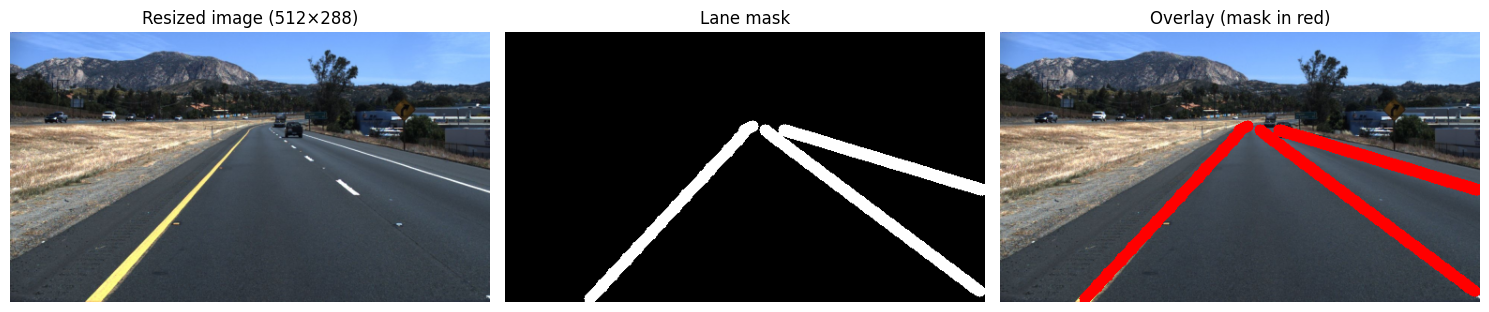

Mask coverage: 6.83% of pixels are lane


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Final image size for U-Net (smaller = faster training)
IMG_HEIGHT = 288
IMG_WIDTH = 512
LANE_THICKNESS = 12

EXTRACTED_IMAGES_ROOT = Path("/content/lane-detection-cv/data/tusimple/extracted/TUSimple/test_set")


def build_lane_mask(annotation, original_size=(1280, 720),
                     target_size=(IMG_WIDTH, IMG_HEIGHT),
                     thickness=LANE_THICKNESS):
    """Build a binary lane mask from a TuSimple annotation entry."""
    orig_w, orig_h = original_size
    target_w, target_h = target_size
    scale_x = target_w / orig_w
    scale_y = target_h / orig_h

    mask = np.zeros((target_h, target_w), dtype=np.uint8)
    h_samples = annotation["h_samples"]
    for lane in annotation["lanes"]:
        pts = []
        for x, y in zip(lane, h_samples):
            if x != -2:
                pts.append([x * scale_x, y * scale_y])
        if len(pts) < 2:
            continue
        pts_arr = np.array(pts, dtype=np.int32)
        cv2.polylines(mask, [pts_arr], isClosed=False,
                      color=255, thickness=thickness)
    return mask


def load_image_resized(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT)):
    """Load an image and resize it. Returns RGB uint8."""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img


# Visualize one example to verify masks look right
import json
with open("/content/lane-detection-cv/data/tusimple/splits/train_label.json") as f:
    train_anns = [json.loads(line) for line in f]

example = train_anns[0]
img_path = EXTRACTED_IMAGES_ROOT / example["raw_file"]
print(f"Sample image: {img_path}")
print(f"Exists: {img_path.exists()}")

img = load_image_resized(img_path)
mask = build_lane_mask(example)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img); axes[0].set_title(f"Resized image ({IMG_WIDTH}×{IMG_HEIGHT})")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Lane mask")
overlay = img.copy()
overlay[mask == 255] = [255, 0, 0]
axes[2].imshow(overlay); axes[2].set_title("Overlay (mask in red)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

print(f"Mask coverage: {(mask == 255).sum() / mask.size * 100:.2f}% of pixels are lane")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TuSimpleSegmentation(Dataset):
    """PyTorch dataset for TuSimple binary lane segmentation."""

    def __init__(self, splits_file, images_root, augment=False):
        self.images_root = Path(images_root)
        self.augment = augment

        self.anns = []
        with open(splits_file) as f:
            for line in f:
                line = line.strip()
                if line:
                    self.anns.append(json.loads(line))

        self.anns = [a for a in self.anns
                      if (self.images_root / a["raw_file"]).exists()]
        print(f"Dataset {Path(splits_file).name}: {len(self.anns)} samples")

    def __len__(self):
        return len(self.anns)

    def __getitem__(self, idx):
        ann = self.anns[idx]
        img_path = self.images_root / ann["raw_file"]

        img = load_image_resized(img_path)
        mask = build_lane_mask(ann)

        if self.augment and np.random.rand() < 0.5:
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        img_t = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        mask_t = torch.from_numpy((mask > 127).astype(np.float32)).unsqueeze(0)
        return img_t, mask_t


SPLITS_DIR = Path("/content/lane-detection-cv/data/tusimple/splits")

train_ds = TuSimpleSegmentation(SPLITS_DIR / "train_label.json",
                                 EXTRACTED_IMAGES_ROOT, augment=True)
val_ds = TuSimpleSegmentation(SPLITS_DIR / "val_label.json",
                               EXTRACTED_IMAGES_ROOT, augment=False)
test_ds = TuSimpleSegmentation(SPLITS_DIR / "test_label.json",
                                EXTRACTED_IMAGES_ROOT, augment=False)

img_t, mask_t = train_ds[0]
print(f"\nSample tensor shapes: img={tuple(img_t.shape)}, mask={tuple(mask_t.shape)}")
print(f"img dtype={img_t.dtype}, range=[{img_t.min():.2f}, {img_t.max():.2f}]")
print(f"mask dtype={mask_t.dtype}, unique values={torch.unique(mask_t).tolist()}")

Dataset train_label.json: 2300 samples
Dataset val_label.json: 300 samples
Dataset test_label.json: 100 samples

Sample tensor shapes: img=(3, 288, 512), mask=(1, 288, 512)
img dtype=torch.float32, range=[0.00, 1.00]
mask dtype=torch.float32, unique values=[0.0, 1.0]


## U-Net architecture

A small U-Net for binary segmentation:
- 4 encoder blocks (DoubleConv + maxpool)
- 4 decoder blocks (transposed conv + DoubleConv)
- Skip connections (encoder → decoder)
- Final 1×1 conv → single logit channel

Channels: 32, 64, 128, 256, 512 (from base=32, doubled at each level).
Smaller than the original U-Net for fast training on T4.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=32):
        super().__init__()
        c = base_channels
        self.enc1 = DoubleConv(in_channels, c)
        self.enc2 = DoubleConv(c, c * 2)
        self.enc3 = DoubleConv(c * 2, c * 4)
        self.enc4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)

        self.up4 = nn.ConvTranspose2d(c * 16, c * 8, 2, stride=2)
        self.dec4 = DoubleConv(c * 16, c * 8)
        self.up3 = nn.ConvTranspose2d(c * 8, c * 4, 2, stride=2)
        self.dec3 = DoubleConv(c * 8, c * 4)
        self.up2 = nn.ConvTranspose2d(c * 4, c * 2, 2, stride=2)
        self.dec2 = DoubleConv(c * 4, c * 2)
        self.up1 = nn.ConvTranspose2d(c * 2, c, 2, stride=2)
        self.dec1 = DoubleConv(c * 2, c)

        self.out_conv = nn.Conv2d(c, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        e4 = self.enc4(F.max_pool2d(e3, 2))
        b = self.bottleneck(F.max_pool2d(e4, 2))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = UNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {total_params:,} (~{total_params * 4 / 1e6:.1f} MB)")

x = torch.randn(2, 3, IMG_HEIGHT, IMG_WIDTH).to(device)
y = model(x)
print(f"Forward pass: input {tuple(x.shape)} → output {tuple(y.shape)}")

Device: cuda
U-Net parameters: 7,763,041 (~31.1 MB)
Forward pass: input (2, 3, 288, 512) → output (2, 1, 288, 512)


## Training

- Loss: BCEWithLogitsLoss with positive-class weight 8 (lane pixels are ~5% of image)
- Optimizer: Adam, lr=1e-3
- Scheduler: ReduceLROnPlateau on val loss
- 30 epochs, mixed-precision (fp16) for speed on T4
- Best model saved after each epoch (lowest val loss)

Checkpoints saving to: /content/drive/MyDrive/lane-detection-cv/checkpoints/unet_best.pth
Training for 30 epochs...
  Batch size: 16
  Train batches/epoch: 144
  Val batches/epoch: 19



/tmp/ipykernel_44810/4221237130.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_44810/4221237130.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_44810/4221237130.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/30 | train 0.3911 | val 0.7913 | lr 0.00100 | 21.2s * saved
Epoch  2/30 | train 0.2148 | val 0.7944 | lr 0.00100 | 20.6s
Epoch  3/30 | train 0.1836 | val 0.3299 | lr 0.00100 | 20.6s * saved
Epoch  4/30 | train 0.1651 | val 0.4570 | lr 0.00100 | 20.6s
Epoch  5/30 | train 0.1454 | val 0.3240 | lr 0.00100 | 20.9s * saved
Epoch  6/30 | train 0.1412 | val 1.9604 | lr 0.00100 | 19.9s
Epoch  7/30 | train 0.1397 | val 0.4081 | lr 0.00100 | 20.3s
Epoch  8/30 | train 0.1307 | val 0.2806 | lr 0.00100 | 20.8s * saved
Epoch  9/30 | train 0.1274 | val 0.2506 | lr 0.00100 | 20.9s * saved
Epoch 10/30 | train 0.1242 | val 0.6058 | lr 0.00100 | 20.2s
Epoch 11/30 | train 0.1274 | val 0.2507 | lr 0.00100 | 20.6s
Epoch 12/30 | train 0.1226 | val 0.2547 | lr 0.00100 | 20.4s
Epoch 13/30 | train 0.1222 | val 0.3308 | lr 0.00050 | 20.5s
Epoch 14/30 | train 0.1112 | val 0.2106 | lr 0.00050 | 20.7s * saved
Epoch 15/30 | train 0.1064 | val 0.2733 | lr 0.00050 | 20.4s
Epoch 16/30 | train 0.1045 | val 0.29

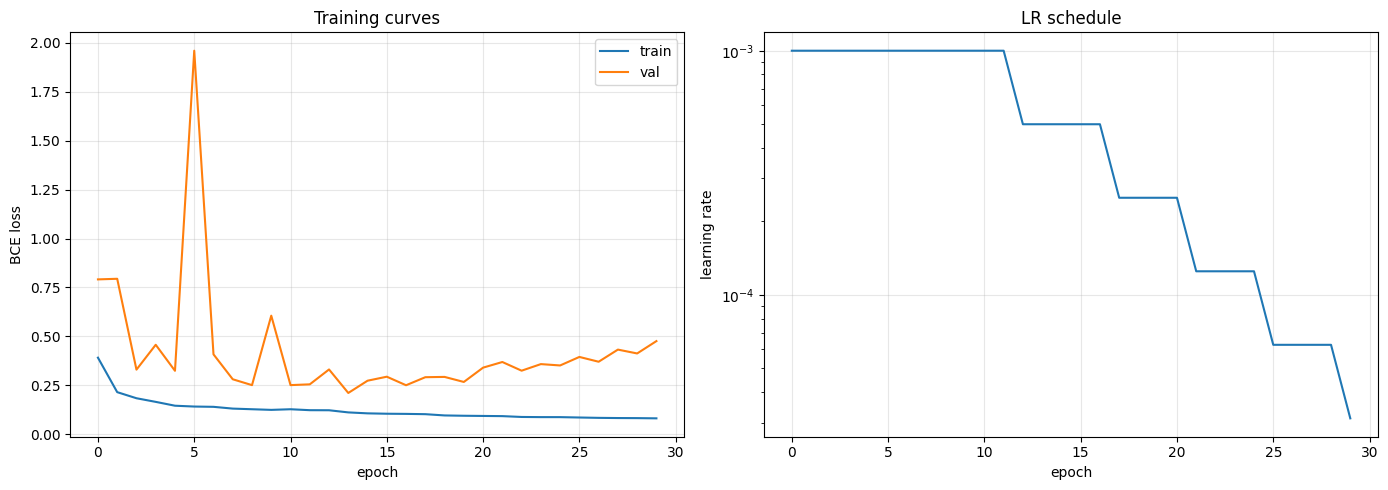

Saved training curves and history.


In [ ]:
import time

BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
POS_WEIGHT = 8.0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)
scaler = torch.cuda.amp.GradScaler()

history = {"train_loss": [], "val_loss": [], "lr": []}
best_val_loss = float("inf")

# Save checkpoints DIRECTLY to Drive — persists across disconnects
CKPT_DIR = DRIVE_PROJECT / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
best_path = CKPT_DIR / "unet_best.pth"
print(f"Checkpoints saving to: {best_path}")

print(f"Training for {NUM_EPOCHS} epochs...")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches/epoch: {len(train_loader)}")
print(f"  Val batches/epoch: {len(val_loader)}")
print()

train_start = time.time()
for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Train
    model.train()
    train_loss_sum = 0.0
    n_train = 0
    for img, mask in train_loader:
        img = img.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            pred = model(img)
            loss = criterion(pred, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss_sum += loss.item() * img.size(0)
        n_train += img.size(0)
    train_loss = train_loss_sum / n_train

    # Val
    model.eval()
    val_loss_sum = 0.0
    n_val = 0
    with torch.no_grad():
        for img, mask in val_loader:
            img = img.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                pred = model(img)
                loss = criterion(pred, mask)
            val_loss_sum += loss.item() * img.size(0)
            n_val += img.size(0)
    val_loss = val_loss_sum / n_val

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
        }, best_path)
        marker = " * saved"
    else:
        marker = ""

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"train {train_loss:.4f} | val {val_loss:.4f} | "
          f"lr {current_lr:.5f} | {epoch_time:.1f}s{marker}")

total_time = time.time() - train_start
print(f"\nTotal training time: {total_time / 60:.1f} min")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Checkpoint saved: {best_path}")

# Plot curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training curves"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["lr"])
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("learning rate")
axes[1].set_title("LR schedule"); axes[1].set_yscale("log"); axes[1].grid(alpha=0.3)
plt.tight_layout()

os.makedirs("/content/lane-detection-cv/results", exist_ok=True)
plt.savefig(DRIVE_PROJECT / "results" / "unet_training_curves.png",
            dpi=120, bbox_inches="tight")
plt.show()

# Save history
with open(DRIVE_PROJECT / "results" / "unet_training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved training curves and history.")

In [ ]:
import shutil
from pathlib import Path

LOCAL_PROJECT = Path("/content/lane-detection-cv")

print("Copying everything important to Drive...\n")

# 1. Splits files (small, important — needed for evaluation later)
local_splits = LOCAL_PROJECT / "data/tusimple/splits"
drive_splits = DRIVE_PROJECT / "data/tusimple/splits"
drive_splits.mkdir(parents=True, exist_ok=True)
for f in local_splits.glob("*.json"):
    shutil.copy2(f, drive_splits / f.name)
    print(f"  Copied: {f.name}")

# 2. Test_label.json (so we don't have to re-download)
src = LOCAL_PROJECT / "data/tusimple/test_label.json"
if src.exists():
    shutil.copy2(src, DRIVE_PROJECT / "data/tusimple/test_label.json")
    print(f"  Copied: test_label.json")

# 3. Checkpoints (already saved during training, but verify)
print("\nCheckpoints in Drive:")
!ls -lh "{DRIVE_PROJECT}/checkpoints/"

# 4. Results (training curves, history JSON)
print("\nResults in Drive:")
!ls -lh "{DRIVE_PROJECT}/results/"

# 5. Save a summary file describing what's in Drive
summary = {
    "trained_at": str(__import__('datetime').datetime.now().isoformat()),
    "best_val_loss": float(best_val_loss),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "pos_weight": POS_WEIGHT,
    "img_size": [IMG_HEIGHT, IMG_WIDTH],
    "lane_thickness": LANE_THICKNESS,
    "n_train": len(train_ds),
    "n_val": len(val_ds),
    "n_test": len(test_ds),
}
with open(DRIVE_PROJECT / "results" / "training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Everything saved to: {DRIVE_PROJECT}")
print("\nYou can safely close this Colab notebook.")
print("To resume work later, just mount Drive and load from this folder.")

Copying everything important to Drive...

  Copied: val_label.json
  Copied: test_label.json
  Copied: train_label.json
  Copied: test_label.json

Checkpoints in Drive:
total 89M
-rw------- 1 root root 89M May 10 14:34 unet_best.pth

Results in Drive:
total 63K
-rw------- 1 root root  61K May 10 14:40 unet_training_curves.png
-rw------- 1 root root 1.9K May 10 14:40 unet_training_history.json

✅ Everything saved to: /content/drive/MyDrive/lane-detection-cv

You can safely close this Colab notebook.
To resume work later, just mount Drive and load from this folder.


## Evaluation — TuSimple metric for U-Net

To compare with our classical pipeline, we need to:
1. Load the best U-Net checkpoint
2. Run inference on each test image
3. Threshold the segmentation mask
4. Group pixels into separate lanes (using sliding window, like classical CV)
5. Fit polynomials to each lane group
6. Compute TuSimple Accuracy / FPR / FNR

This pipeline reuses our existing `sliding_window_search` and `polyfit` modules
on the U-Net's predicted mask, treating U-Net as a drop-in replacement for the
HLS+Sobel thresholding step.

In [ ]:
import sys
import importlib

# Reload our project modules (they may have been imported earlier)
for module_name in ["sliding_window", "polyfit", "evaluate"]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from sliding_window import sliding_window_search
from polyfit import fit_lane_polynomial, evaluate_polynomial
from evaluate import (
    match_lanes_one_frame, evaluate_dataset, TuSimpleMetrics,
    PIXEL_THRESH
)

# Load best checkpoint
ckpt_path = DRIVE_PROJECT / "checkpoints" / "unet_best.pth"
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f"Loaded checkpoint:")
print(f"  epoch:    {checkpoint['epoch']}")
print(f"  val_loss: {checkpoint['val_loss']:.4f}")

# Build a fresh model and load weights
model = UNet().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"  model loaded with {sum(p.numel() for p in model.parameters()):,} params")

Loaded checkpoint:
  epoch:    14
  val_loss: 0.2106
  model loaded with 7,763,041 params


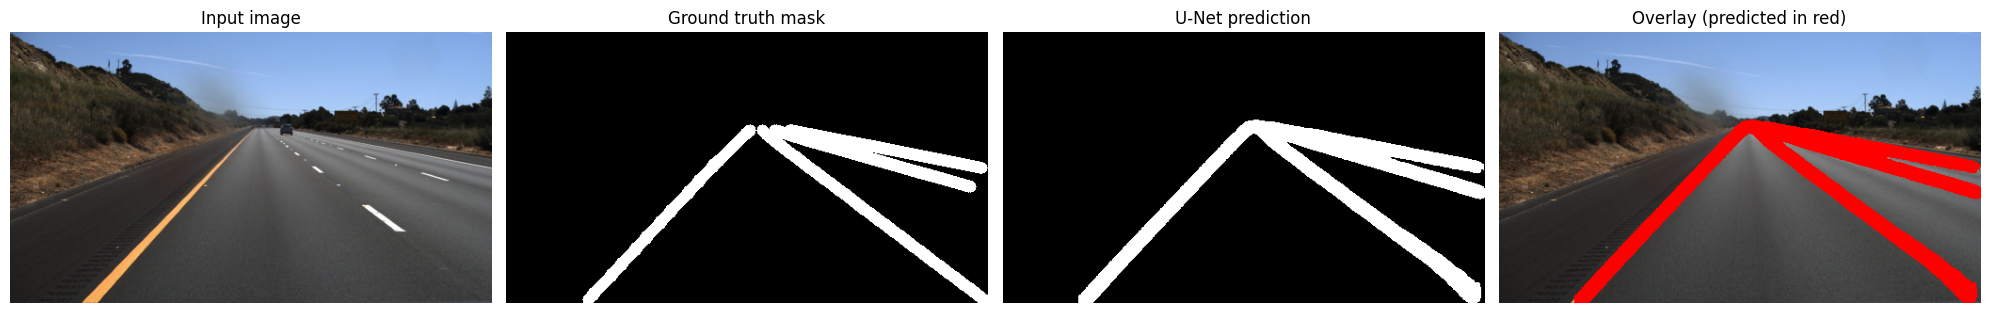

Predicted mask coverage: 10.22%


In [ ]:
# Quick sanity check: run U-Net on one test image and visualize the mask
test_idx = 0
test_ann = test_ds.anns[test_idx]
test_img_path = test_ds.images_root / test_ann["raw_file"]

# Load and preprocess
img_rgb = load_image_resized(test_img_path)
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    logits = model(img_t)
    probs = torch.sigmoid(logits)

# Convert to numpy mask
mask_pred = (probs[0, 0].cpu().numpy() > 0.5).astype(np.uint8) * 255

# Build the GT mask from annotation for comparison
mask_gt = build_lane_mask(test_ann)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(img_rgb); axes[0].set_title("Input image"); axes[0].axis("off")
axes[1].imshow(mask_gt, cmap="gray"); axes[1].set_title("Ground truth mask"); axes[1].axis("off")
axes[2].imshow(mask_pred, cmap="gray"); axes[2].set_title("U-Net prediction"); axes[2].axis("off")

overlay = img_rgb.copy()
overlay[mask_pred == 255] = [255, 0, 0]
axes[3].imshow(overlay); axes[3].set_title("Overlay (predicted in red)"); axes[3].axis("off")
plt.tight_layout(); plt.show()

print(f"Predicted mask coverage: {(mask_pred == 255).sum() / mask_pred.size * 100:.2f}%")

In [ ]:
# We need our project's PerspectiveWarper to do BEV transform
from perspective import PerspectiveWarper
warper = PerspectiveWarper()

def unet_predict_lanes(model, image_rgb_orig_size, h_samples,
                        prob_threshold=0.5):
    """U-Net inference + BEV-based lane separation.

    1. Run U-Net on a resized version of the image
    2. Resize the mask back to original size (1280x720)
    3. Warp mask to bird's-eye view (using our existing PerspectiveWarper)
    4. Use sliding window in BEV space to separate left/right lanes
    5. Fit polynomials in BEV space
    6. Sample polynomials at GT's h_samples y-rows back in camera view
    """
    orig_h, orig_w = image_rgb_orig_size.shape[:2]

    # 1. Run U-Net on resized input
    img_resized = cv2.resize(image_rgb_orig_size, (IMG_WIDTH, IMG_HEIGHT),
                              interpolation=cv2.INTER_AREA)
    img_t = (torch.from_numpy(img_resized.astype(np.float32) / 255.0)
             .permute(2, 0, 1).unsqueeze(0).to(device))

    with torch.no_grad():
        logits = model(img_t)
        probs = torch.sigmoid(logits)

    # 2. Threshold and resize mask back to camera-view size (1280x720)
    mask_small = (probs[0, 0].cpu().numpy() > prob_threshold).astype(np.uint8) * 255
    mask_camera = cv2.resize(mask_small, (orig_w, orig_h),
                              interpolation=cv2.INTER_NEAREST)

    # 3. Warp the binary mask to BEV
    # warp_image expects (H, W, 3) so we expand the binary mask
    mask_3ch = np.dstack([mask_camera, mask_camera, mask_camera])
    mask_bev_3ch = warper.warp_image(mask_3ch)
    mask_bev = (mask_bev_3ch[:, :, 0] > 127).astype(np.uint8) * 255

    # 4. Run sliding window on the BEV mask
    sw = sliding_window_search(mask_bev)

    # 5. Fit polynomials in BEV space
    pred_lanes = []
    for is_detected, x_idx, y_idx in [
        (sw["left_detected"], sw["left_x_idx"], sw["left_y_idx"]),
        (sw["right_detected"], sw["right_x_idx"], sw["right_y_idx"]),
    ]:
        if not is_detected:
            continue
        coeffs = fit_lane_polynomial(x_idx, y_idx)
        if coeffs is None:
            continue

        # Sample BEV polynomial densely
        H_bev = mask_bev.shape[0]
        y_bev_dense = np.linspace(0, H_bev - 1, num=H_bev * 2)
        x_bev_dense = evaluate_polynomial(coeffs, y_bev_dense)
        bev_points = np.stack([x_bev_dense, y_bev_dense], axis=1)

        # Map back to camera view
        cam_points = warper.unwarp_points(bev_points)
        cam_x = cam_points[:, 0]
        cam_y = cam_points[:, 1]

        # Sort by cam_y for interpolation
        order = np.argsort(cam_y)
        cam_y_sorted = cam_y[order]
        cam_x_sorted = cam_x[order]

        # Sample at h_samples y-rows
        pred_x = np.full_like(h_samples, -2.0, dtype=np.float32)
        in_range = (h_samples >= cam_y_sorted.min() - 5) & \
                   (h_samples <= cam_y_sorted.max() + 5)
        if in_range.any():
            pred_x[in_range] = np.interp(
                h_samples[in_range], cam_y_sorted, cam_x_sorted
            )

        pred_lanes.append(pred_x)

    return pred_lanes


# Quick sanity check on sample 0
test_ann = test_ds.anns[0]
test_img_path = test_ds.images_root / test_ann["raw_file"]
img_orig = cv2.imread(str(test_img_path))
img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

h_samples = np.array(test_ann["h_samples"], dtype=np.float32)
gt_lanes = [np.array(lane, dtype=np.float32) for lane in test_ann["lanes"]]

pred_lanes = unet_predict_lanes(model, img_orig_rgb, h_samples)

print(f"GT lanes: {len(gt_lanes)} (visible: {sum(1 for l in gt_lanes if (l != -2).any())})")
print(f"U-Net predicted lanes: {len(pred_lanes)}")
for i, p in enumerate(pred_lanes):
    n_valid = (p != -2).sum()
    if n_valid > 0:
        print(f"  Lane {i}: {n_valid} valid points, x range [{p[p != -2].min():.1f}, {p[p != -2].max():.1f}]")

GT lanes: 4 (visible: 4)
U-Net predicted lanes: 2
  Lane 0: 31 valid points, x range [228.1, 509.7]
  Lane 1: 31 valid points, x range [863.8, 1250.5]


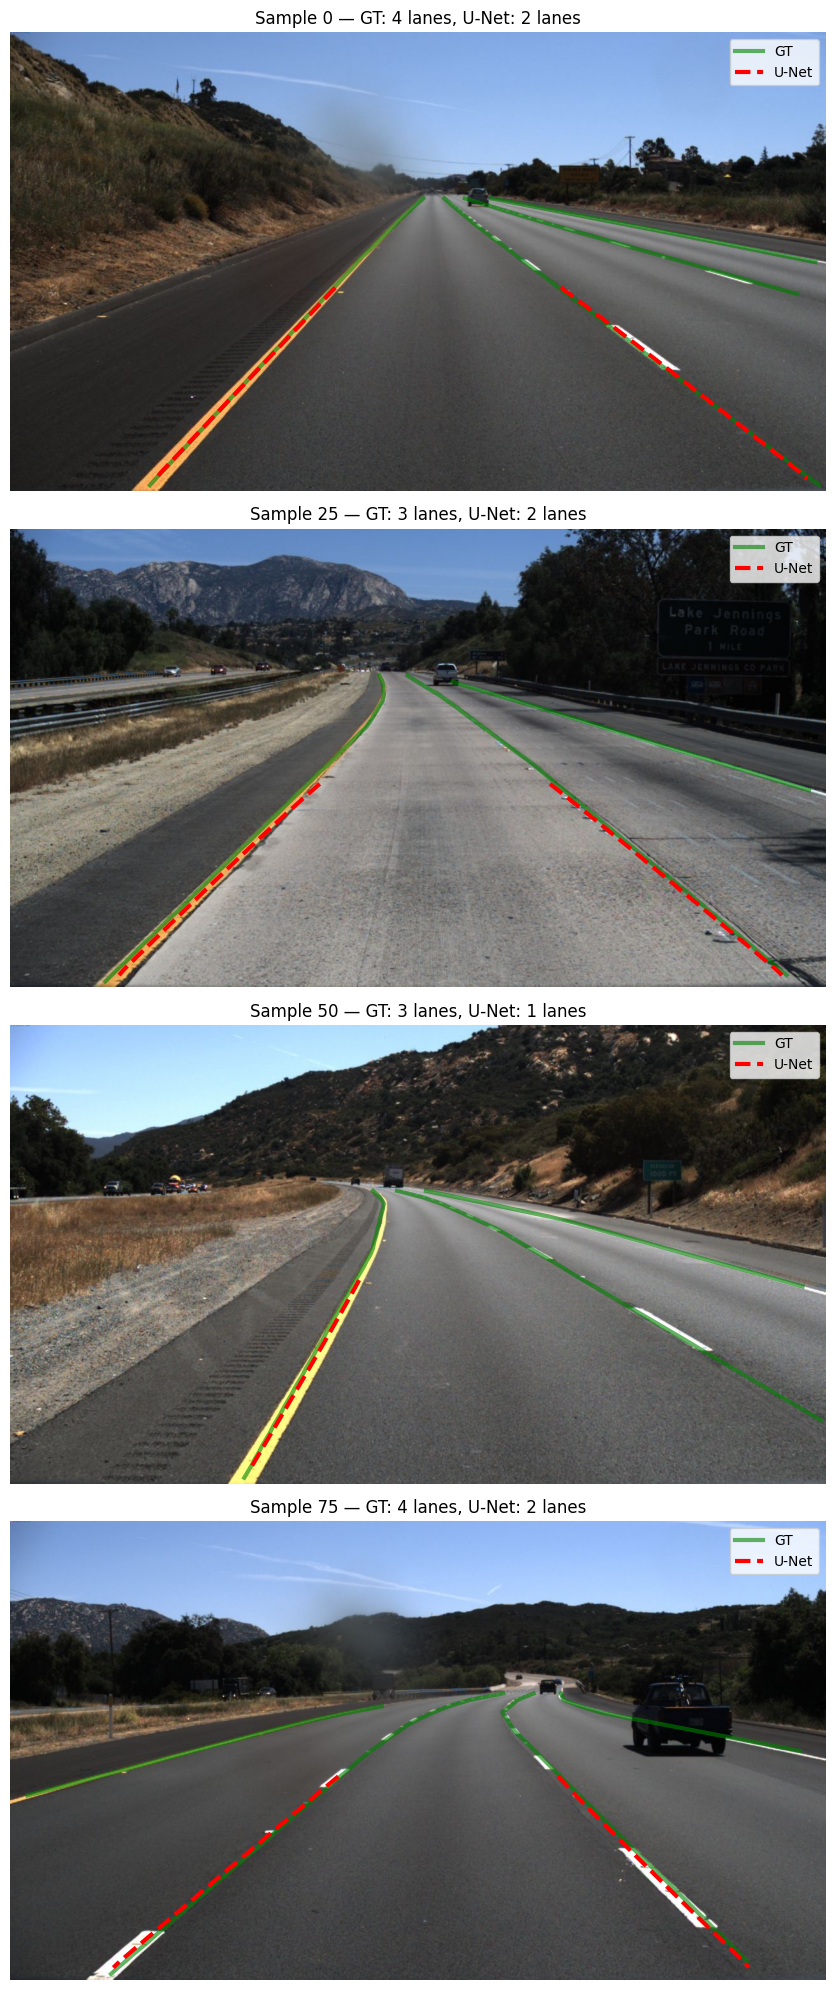

In [ ]:
# Show 4 examples of U-Net predictions vs GT
sample_indices = [0, 25, 50, 75]
fig, axes = plt.subplots(len(sample_indices), 1, figsize=(14, 5 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    ann = test_ds.anns[idx]
    img_path = test_ds.images_root / ann["raw_file"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h_samples = np.array(ann["h_samples"], dtype=np.float32)
    gt_lanes = [np.array(l, dtype=np.float32) for l in ann["lanes"]]
    pred_lanes = unet_predict_lanes(model, img, h_samples)

    ax.imshow(img)

    # GT in green
    for gi, gt in enumerate(gt_lanes):
        valid = gt != -2
        if valid.any():
            ax.plot(gt[valid], h_samples[valid], "g-", linewidth=3, alpha=0.6,
                    label="GT" if gi == 0 else None)

    # Predictions in red
    for pi, pred in enumerate(pred_lanes):
        valid = pred != -2
        if valid.any():
            ax.plot(pred[valid], h_samples[valid], "r--", linewidth=3,
                    label="U-Net" if pi == 0 else None)

    ax.set_title(f"Sample {idx} — GT: {len(gt_lanes)} lanes, U-Net: {len(pred_lanes)} lanes")
    ax.legend(loc="upper right")
    ax.axis("off")

plt.tight_layout()
plt.savefig(DRIVE_PROJECT / "results" / "unet_examples.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
from tqdm.notebook import tqdm

print(f"Evaluating U-Net on {len(test_ds.anns)} test frames...")

frame_results = []
for ann in tqdm(test_ds.anns):
    img_path = test_ds.images_root / ann["raw_file"]
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h_samples = np.array(ann["h_samples"], dtype=np.float32)
    gt_lanes = [np.array(l, dtype=np.float32) for l in ann["lanes"]]

    pred_lanes = unet_predict_lanes(model, img, h_samples)
    fr = match_lanes_one_frame(pred_lanes, gt_lanes)
    frame_results.append(fr)

metrics = evaluate_dataset(frame_results)
print()
print(metrics)

# Save metrics for the report
metrics_dict = {
    "method": "U-Net (single-frame)",
    "accuracy": float(metrics.accuracy),
    "fpr": float(metrics.fpr),
    "fnr": float(metrics.fnr),
    "n_frames": metrics.n_frames,
    "total_pred_lanes": metrics.total_pred_lanes,
    "total_gt_lanes": metrics.total_gt_lanes,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "checkpoint_val_loss": float(checkpoint["val_loss"]),
}
with open(DRIVE_PROJECT / "results" / "tusimple_metrics_unet.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)
print(f"\nSaved metrics to: {DRIVE_PROJECT / 'results' / 'tusimple_metrics_unet.json'}")

Evaluating U-Net on 100 test frames...


  0%|          | 0/100 [00:00<?, ?it/s]


TuSimple metrics over 100 frames:
  Accuracy:  99.53%
  FPR:       20.94%
  FNR:       58.97%
  Predicted lanes: 191
  GT lanes:        368

Saved metrics to: /content/drive/MyDrive/lane-detection-cv/results/tusimple_metrics_unet.json


In [ ]:
import json
import shutil
from pathlib import Path

LOCAL_PROJECT = Path("/content/lane-detection-cv")

print("=" * 70)
print("Saving everything to Drive...")
print("=" * 70)

# 1. Copy splits + test_label.json to Drive
local_splits = LOCAL_PROJECT / "data/tusimple/splits"
drive_splits = DRIVE_PROJECT / "data/tusimple/splits"
drive_splits.mkdir(parents=True, exist_ok=True)
for f in local_splits.glob("*.json"):
    shutil.copy2(f, drive_splits / f.name)

src = LOCAL_PROJECT / "data/tusimple/test_label.json"
if src.exists():
    shutil.copy2(src, DRIVE_PROJECT / "data/tusimple/test_label.json")

# 2. Save a summary file
import datetime
summary = {
    "trained_at": datetime.datetime.now().isoformat(),
    "best_val_loss": float(best_val_loss),
    "best_epoch": int(checkpoint["epoch"]),
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "pos_weight": POS_WEIGHT,
    "img_size_height_width": [IMG_HEIGHT, IMG_WIDTH],
    "lane_thickness": LANE_THICKNESS,
    "n_train": len(train_ds),
    "n_val": len(val_ds),
    "n_test": len(test_ds),
    "model_params": int(sum(p.numel() for p in model.parameters())),
    "tusimple_metrics_unet": {
        "accuracy": float(metrics.accuracy),
        "fpr": float(metrics.fpr),
        "fnr": float(metrics.fnr),
        "n_frames": metrics.n_frames,
        "total_pred_lanes": metrics.total_pred_lanes,
        "total_gt_lanes": metrics.total_gt_lanes,
    },
}
with open(DRIVE_PROJECT / "results" / "training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Drive contents:")
for sub in ["checkpoints", "results", "data/tusimple/splits"]:
    p = DRIVE_PROJECT / sub
    if p.exists():
        print(f"\n  {p}:")
        !ls -lh "{p}"

print("\n" + "=" * 70)
print("All artifacts saved to Drive. Safe to disconnect.")
print("=" * 70)

Saving everything to Drive...

✅ Drive contents:

  /content/drive/MyDrive/lane-detection-cv/checkpoints:
total 89M
-rw------- 1 root root 89M May 10 14:34 unet_best.pth

  /content/drive/MyDrive/lane-detection-cv/results:
total 2.8M
-rw------- 1 root root  557 May 10 15:45 training_summary.json
-rw------- 1 root root  273 May 10 15:44 tusimple_metrics_unet.json
-rw------- 1 root root 2.8M May 10 14:52 unet_examples.png
-rw------- 1 root root  61K May 10 14:40 unet_training_curves.png
-rw------- 1 root root 1.9K May 10 14:40 unet_training_history.json

  /content/drive/MyDrive/lane-detection-cv/data/tusimple/splits:
total 3.4M
-rw------- 1 root root 131K May 10 14:15 test_label.json
-rw------- 1 root root 2.8M May 10 14:15 train_label.json
-rw------- 1 root root 475K May 10 14:15 val_label.json

All artifacts saved to Drive. Safe to disconnect.
